# **Phase 2.0 : Import Required Libraries**

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

from pathlib import Path

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

**Github Repo Connection**

In [59]:
!git clone https://github.com/edusatyaki/ProjectDrive.git

fatal: destination path 'ProjectDrive' already exists and is not an empty directory.


# **Phase 2.1 : Load Cleaned Dataset**

In [60]:
CLEANED_FOLDER = Path(
    "ProjectDrive/Group-C/NYC Yellow Taxi 2025/Data Cleaning/Cleaned Dataset"
)

df = pd.read_parquet(
    CLEANED_FOLDER /
    "yellow_tripdata_2025-01_cleaned.parquet"
)

print(df.shape)

df.head()

(2814358, 28)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,Airport_fee,cbd_congestion_fee,trip_duration,pickup_hour,pickup_day,pickup_month,pickup_year,is_weekend,fare_per_mile,tip_pct
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,...,0.0,0.0,8.350000,0,Wednesday,January,2025,False,6.250000,30.000000
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,...,0.0,0.0,2.550000,0,Wednesday,January,2025,False,10.200000,39.607843
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,...,0.0,0.0,1.950000,0,Wednesday,January,2025,False,8.500000,39.215686
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,...,0.0,0.0,5.566667,0,Wednesday,January,2025,False,13.846154,0.000000
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,...,0.0,0.0,3.533333,0,Wednesday,January,2025,False,8.787879,0.000000


# **Phase 2.2 : Dataset Overview**

In [61]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2814358 entries, 0 to 2814357
Data columns (total 28 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,trip_duration,pickup_hour,pickup_year,fare_per_mile,tip_pct
count,2.814358e+06,2814358,2814358,2.814358e+06,2.814358e+06,2.814358e+06,2.814358e+06,2.814358e+06,2.814358e+06,2.814358e+06,...,2.814358e+06,2.814358e+06,2.814358e+06,2.814358e+06,2.814358e+06,2.814358e+06,2.814358e+06,2.814358e+06,2.814358e+06,2.814358e+06
mean,1.776678e+00,2025-01-17 02:34:10.897657,2025-01-17 02:48:46.926184,1.306511e+00,3.176998e+00,2.422430e+00,1.670561e+02,1.661377e+02,1.175406e+00,1.793610e+01,...,9.871491e-01,2.736629e+01,2.325499e+00,1.329636e-01,4.873381e-01,1.460048e+01,1.438705e+01,2.025000e+03,1.164224e+01,2.245739e+01
min,1.000000e+00,2024-12-31 20:47:55,2024-12-31 20:54:00,1.000000e+00,1.000000e-02,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e-02,...,0.000000e+00,1.010000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.666667e-02,0.000000e+00,2.024000e+03,2.386635e-04,0.000000e+00
25%,2.000000e+00,2025-01-09 16:23:35.250000,2025-01-09 16:40:12.500000,1.000000e+00,9.900000e-01,1.000000e+00,1.320000e+02,1.160000e+02,1.000000e+00,8.600000e+00,...,1.000000e+00,1.596000e+01,2.500000e+00,0.000000e+00,0.000000e+00,7.066667e+00,1.100000e+01,2.025000e+03,5.804416e+00,1.176471e+01
50%,2.000000e+00,2025-01-16 21:12:27,2025-01-16 21:25:51,1.000000e+00,1.630000e+00,1.000000e+00,1.620000e+02,1.630000e+02,1.000000e+00,1.210000e+01,...,1.000000e+00,2.035000e+01,2.500000e+00,0.000000e+00,7.500000e-01,1.135000e+01,1.500000e+01,2.025000e+03,7.250000e+00,2.558824e+01
75%,2.000000e+00,2025-01-24 17:36:17.750000,2025-01-24 17:52:03.750000,1.000000e+00,3.000000e+00,1.000000e+00,2.340000e+02,2.360000e+02,1.000000e+00,1.910000e+01,...,1.000000e+00,2.845000e+01,2.500000e+00,0.000000e+00,7.500000e-01,1.813333e+01,1.900000e+01,2.025000e+03,9.113924e+00,3.105114e+01
max,2.000000e+00,2025-02-01 00:00:44,2025-02-01 01:10:26,6.000000e+00,9.758000e+01,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,5.000000e+02,...,1.000000e+00,6.029500e+02,2.500000e+00,1.750000e+00,7.500000e-01,2.965333e+02,2.300000e+01,2.025000e+03,4.500000e+04,4.000000e+05
std,4.164723e-01,NaN,NaN,7.419463e-01,4.300687e+00,1.145500e+01,6.294699e+01,6.885297e+01,4.781006e-01,1.690290e+01,...,1.126310e-01,2.133636e+01,6.370255e-01,4.636883e-01,3.577782e-01,1.179973e+01,5.526585e+00,2.731608e-03,1.394135e+02,2.390700e+02


In [62]:
df.isnull().sum()

,0
VendorID,0
tpep_pickup_datetime,0
tpep_dropoff_datetime,0
passenger_count,0
trip_distance,0
RatecodeID,0
store_and_fwd_flag,0
PULocationID,0
DOLocationID,0
payment_type,0


# **Phase 2.3 : Monthly Trip Volume & Revenue**

In [63]:
# month_order = [
#     "January", "February", "March", "April", "May", "June",
#     "July", "August", "September", "October", "November", "December"
# ]

monthly_summary = (

    df.groupby("pickup_month")

      .agg(

          Trips=("pickup_month","count"),

          Revenue=("fare_amount","sum"),

          Average_Fare=("fare_amount","mean")

      )

      .reset_index()

)

monthly_summary

,pickup_month,Trips,Revenue,Average_Fare
0,December,21,401.60,19.12381
1,February,1,6.50,6.50000
2,January,2814336,50478211.42,17.93610


### Insight

January recorded the total trip volume for this cleaned dataset.
This visualization helps compare monthly demand when additional months are added.

**Visualization**

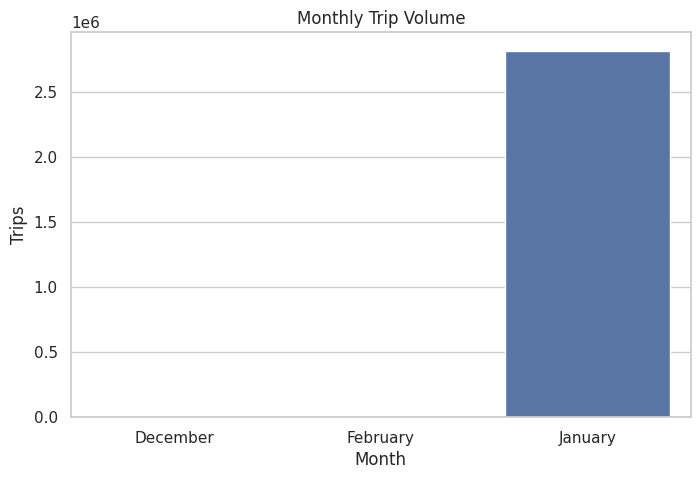

In [64]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=monthly_summary,
    x="pickup_month",
    y="Trips"
)

plt.title("Monthly Trip Volume")

plt.xlabel("Month")

plt.ylabel("Trips")

plt.show()

**Revenue Chart**

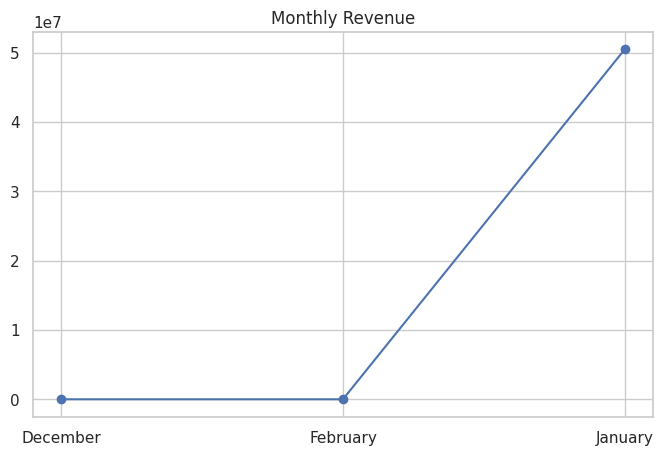

In [65]:
plt.figure(figsize=(8,5))

plt.plot(

    monthly_summary["pickup_month"],

    monthly_summary["Revenue"],

    marker="o"

)

plt.title("Monthly Revenue")

plt.show()

### Insight

Revenue increases with trip demand.
Future months can be compared to identify seasonal trends.

# **Phase 2.4 : Hourly Demand Analysis**

In [66]:
hourly = (

    df.groupby("pickup_hour")

      .size()

      .reset_index(name="Trips")

)

hourly

,pickup_hour,Trips
0,0,65067
1,1,43652
2,2,29425
3,3,19134
4,4,12324
5,5,15370
6,6,34857
7,7,74081
8,8,105731
9,9,122111


**Visualization**

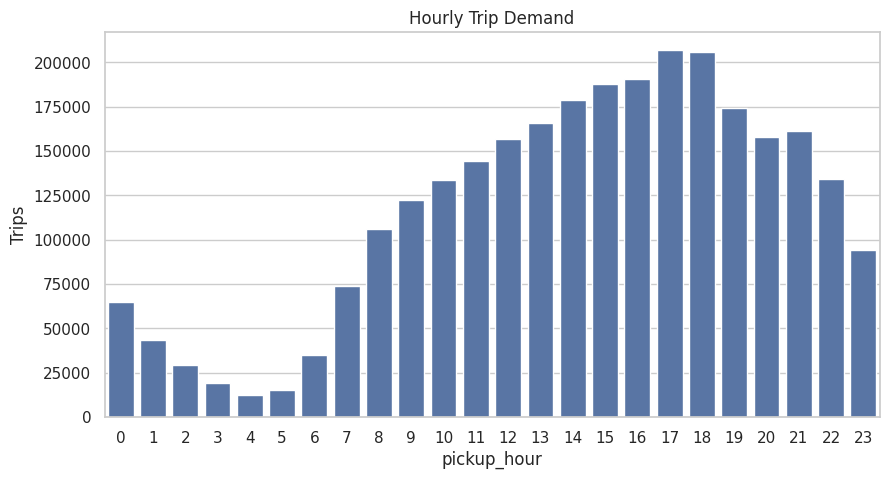

In [67]:
plt.figure(figsize=(10,5))

sns.barplot(

    data=hourly,

    x="pickup_hour",

    y="Trips"

)

plt.title("Hourly Trip Demand")

plt.show()

### Insight

Peak travel hours represent the busiest periods for NYC taxis.
These hours can be useful for driver scheduling.

# **Phase 2.5 : Weekday vs Weekend Heatmap**

In [68]:
heatmap = pd.pivot_table(

    df,

    values="fare_amount",

    index="pickup_hour",

    columns="is_weekend",

    aggfunc="count"

)

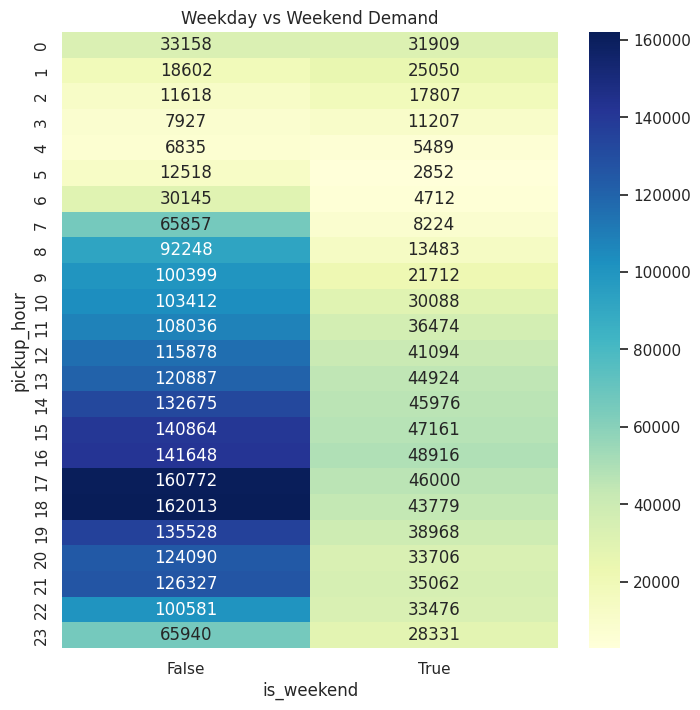

In [69]:
plt.figure(figsize=(8,8))

sns.heatmap(

    heatmap,

    cmap="YlGnBu",

    annot=True,

    fmt=".0f"

)

plt.title("Weekday vs Weekend Demand")

plt.show()

### Insight

The heatmap highlights differences between weekday and weekend demand across different hours.

# **Phase 2.6 : Fare Distribution**

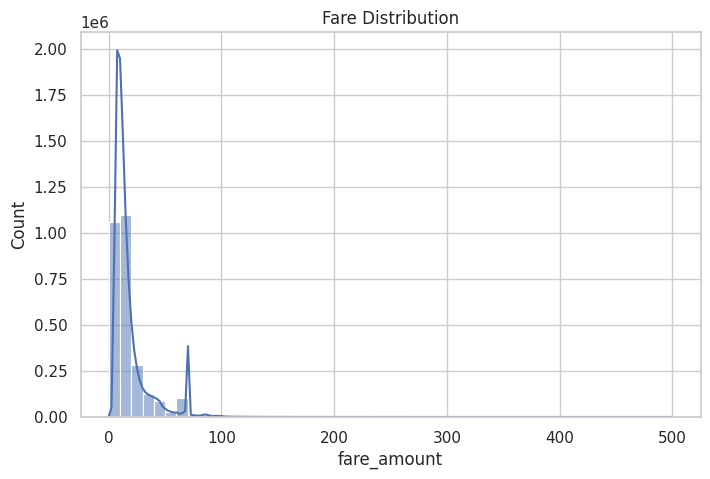

In [70]:
plt.figure(figsize=(8,5))

sns.histplot(

    df["fare_amount"],

    bins=50,

    kde=True

)

plt.title("Fare Distribution")

plt.show()

### Insight

Most trips fall within the lower fare range, while high-fare trips are comparatively rare.

# **Phase 2.7 : Airport vs Standard Trips**

In [71]:
airport = df[df["Airport_fee"] > 0]

standard = df[df["Airport_fee"] == 0]

In [72]:
comparison = pd.DataFrame({

    "Trip Type":[

        "Airport",

        "Standard"

    ],

    "Average Fare":[

        airport["fare_amount"].mean(),

        standard["fare_amount"].mean()

    ],

    "Average Distance":[

        airport["trip_distance"].mean(),

        standard["trip_distance"].mean()

    ]

})

comparison

,Trip Type,Average Fare,Average Distance
0,Airport,53.645552,13.053124
1,Standard,14.999829,2.364915


**Visualization**

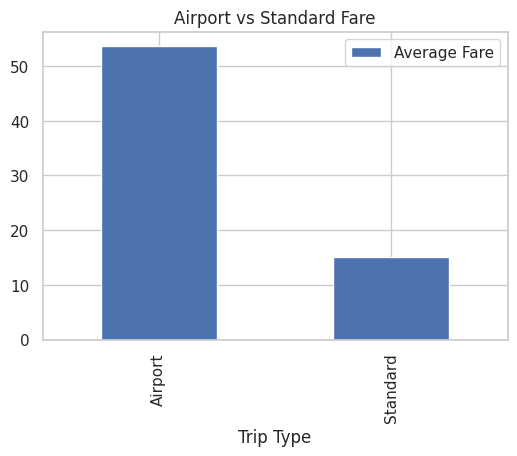

In [73]:
comparison.plot(

    x="Trip Type",

    y="Average Fare",

    kind="bar",

    figsize=(6,4)

)

plt.title("Airport vs Standard Fare")

plt.show()

### Insight

Airport trips generally have higher average fares than standard city trips.

# **Phase 2.8 : Tip Percentage by Hour**

In [74]:
tip_hour = (

    df.groupby("pickup_hour")["tip_pct"]

      .mean()

      .reset_index()

)

tip_hour

,pickup_hour,tip_pct
0,0,22.299256
1,1,22.481046
2,2,22.110133
3,3,21.492019
4,4,19.698352
5,5,18.277217
6,6,19.096196
7,7,20.571133
8,8,21.402543
9,9,21.329640


**Visualization**

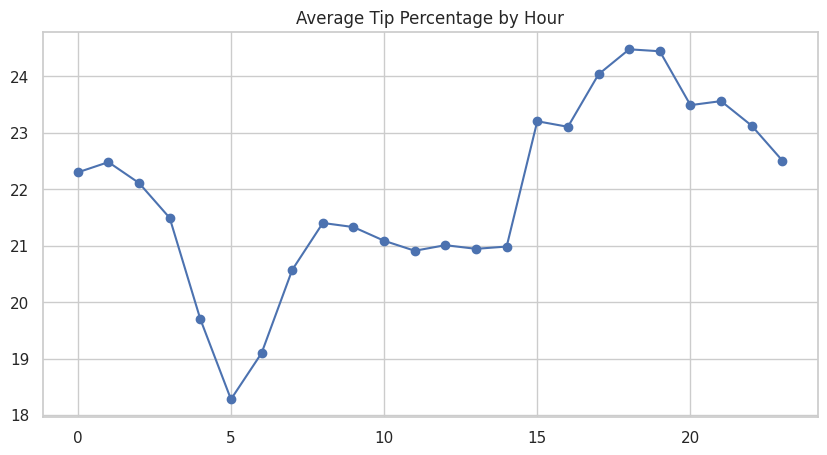

In [75]:
plt.figure(figsize=(10,5))

plt.plot(

    tip_hour["pickup_hour"],

    tip_hour["tip_pct"],

    marker="o"

)

plt.title("Average Tip Percentage by Hour")

plt.show()

### Insight

Late-night hours may show different tipping behaviour compared to daytime trips.

# **Phase 2.9 : CBD Congestion Fee Analysis**

In [76]:
cbd = (

    df.groupby("congestion_surcharge")

      .agg(

          Trips=("fare_amount","count"),

          Revenue=("fare_amount","sum")

      )

      .reset_index()

)

cbd

,congestion_surcharge,Trips,Revenue
0,0.0,196443,7972420.89
1,2.5,2617915,42506198.63


**Visualization**

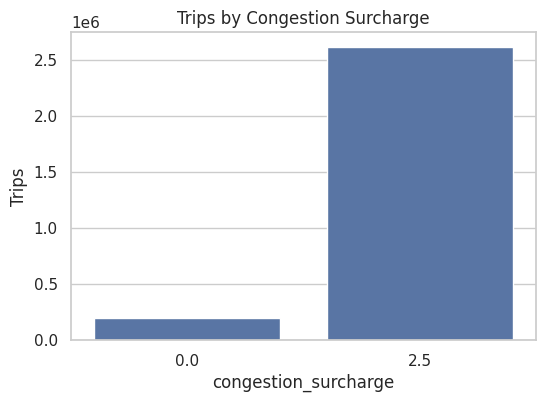

In [77]:
plt.figure(figsize=(6,4))

sns.barplot(

    data=cbd,

    x="congestion_surcharge",

    y="Trips"

)

plt.title("Trips by Congestion Surcharge")

plt.show()

### Insight

Trips with congestion surcharge indicate travel through CBD areas and help evaluate congestion fee impact.

# **Phase 2.10 : Driver Revenue Optimization**

In [78]:
driver = (

    df.groupby("pickup_hour")

      .agg(

          Average_Revenue=(

              "fare_amount",

              "mean"

          ),

          Trips=(

              "fare_amount",

              "count"

          )

      )

      .reset_index()

)

driver["Revenue Score"] = (

    driver["Average_Revenue"]

    *

    driver["Trips"]

)

driver.sort_values(

    "Revenue Score",

    ascending=False

).head(10)

,pickup_hour,Average_Revenue,Trips,Revenue Score
17,17,17.366808,206772,3590969.64
16,16,18.814551,190564,3585376.14
15,15,18.743066,188025,3524164.92
18,18,16.355629,205792,3365857.62
14,14,18.656787,178651,3333053.60
13,13,18.052650,165811,2993327.99
19,19,17.044199,174496,2974144.48
21,21,17.979045,161389,2901620.16
20,20,17.756945,157796,2801974.82
12,12,17.505178,156972,2747822.84


**Visualization**

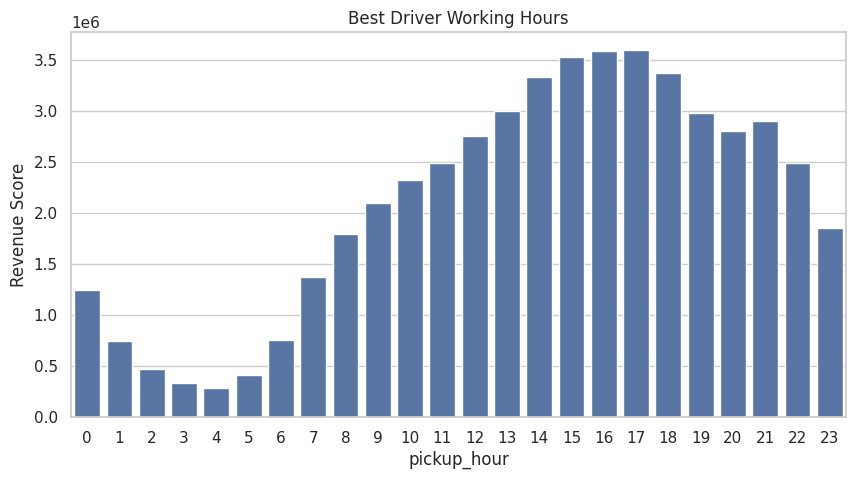

In [79]:
plt.figure(figsize=(10,5))

sns.barplot(

    data=driver,

    x="pickup_hour",

    y="Revenue Score"

)

plt.title("Best Driver Working Hours")

plt.show()

### Insight

Hours with the highest revenue score represent the most profitable working periods for taxi drivers.

# **Phase 2.11 : Correlation Heatmap**

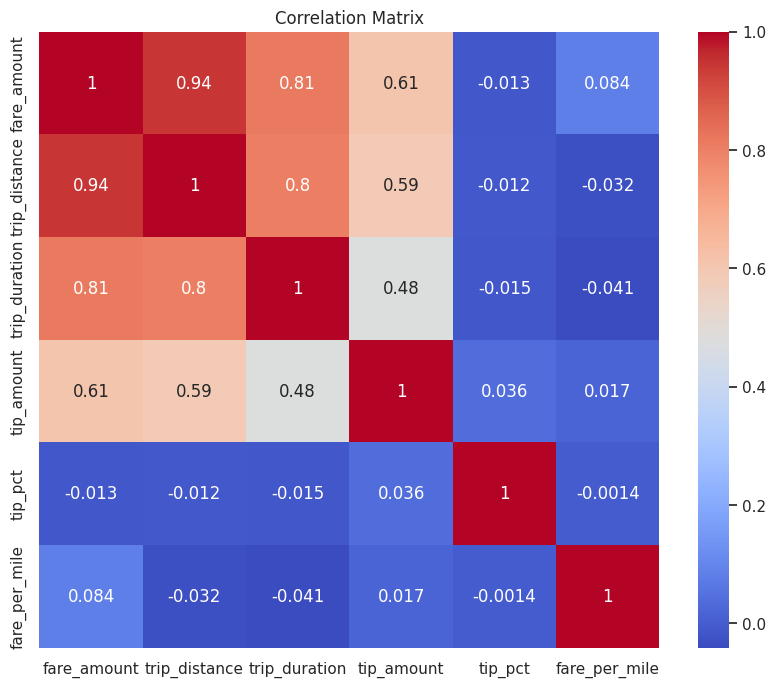

In [80]:
plt.figure(figsize=(10,8))

corr = df[

    [

        "fare_amount",

        "trip_distance",

        "trip_duration",

        "tip_amount",

        "tip_pct",

        "fare_per_mile"

    ]

].corr()

sns.heatmap(

    corr,

    annot=True,

    cmap="coolwarm"

)

plt.title("Correlation Matrix")

plt.show()

### Insight

Fare amount is positively correlated with trip distance and trip duration, while tip amount generally increases with fare amount.

# **Phase 2.12 : Dashboard CSV Export**

In [81]:
DASHBOARD = Path("Dashboard")

DASHBOARD.mkdir(exist_ok=True)

In [82]:
monthly_summary.to_csv(

    DASHBOARD / "monthly_summary.csv",

    index=False

)

hourly.to_csv(

    DASHBOARD / "hourly_demand.csv",

    index=False

)

comparison.to_csv(

    DASHBOARD / "airport_vs_standard.csv",

    index=False

)

tip_hour.to_csv(

    DASHBOARD / "tip_analysis.csv",

    index=False

)

cbd.to_csv(

    DASHBOARD / "congestion_surcharge.csv",

    index=False

)

driver.to_csv(

    DASHBOARD / "driver_revenue.csv",

    index=False

)

print("Dashboard CSV files saved successfully.")

Dashboard CSV files saved successfully.
